In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
data = np.asarray(pd.read_csv('./data/data.csv', header=None))
X = data[:, 0:2]
y = data[:, 2]

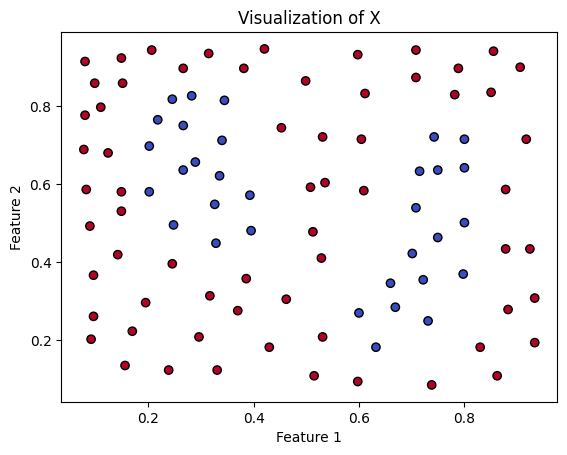

In [28]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Visualization of X')
plt.show()


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [33]:
# Find the right parameters for this model to achieve 100% accuracy on the train dataset.
model = SVC(kernel='rbf', gamma=27)

model.fit(X_train, y_train)

y_pred = model.predict(X_train)

acc = accuracy_score(y_train, y_pred)
acc

1.0

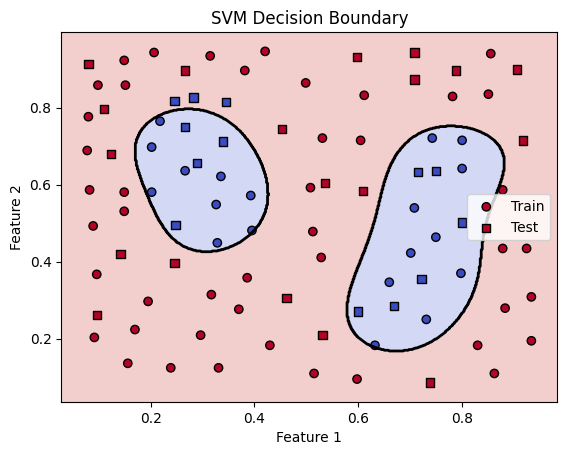

In [34]:
x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', marker='s', label='Test')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary')
plt.legend()
plt.show()


In [35]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
acc

0.90625